## New York Taxi Data Processing

### 1. Objective
Build a data processing pipeline to clean, transform, and analyze New York City taxi trip data, generating features such as trip distance, hour of day, and weekday for further analytics.

### 2. Import Libraries

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Feature engineering
from haversine import haversine_vector

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

### 3. Read Data

In [ ]:
# Load your dataset and verify that all columns and rows are displayed correctly

import pandas as pd

# Source file
df = pd.read_csv(r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\NY Trip Duration\data\raw\train.csv")

# Explore data
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 189.2 MB
None


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


### 4. Transform Data

In [ ]:
# Convert dates to datetime format
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

# Filter valid coordinates from NYC
df = df[(df['pickup_longitude'].between(-74.05, -73.75)) &
        (df['pickup_latitude'].between(40.63, 40.85))]

# Filter long runs (optional)
df = df[df['trip_duration'].between(60, 3600*3)]  # trips between 1min and 3 hours

In [ ]:
print(df[["pickup_datetime","dropoff_datetime"]].dtypes)

pickup_datetime     datetime64[us]
dropoff_datetime    datetime64[us]
dtype: object


### 5. Generate Features

In [ ]:
# Use haversine function to calculate the distance between point A(pickup) and B(dropoff). 
# The result will be store in a new column "distance_km". There will be also two additional columns "hour" and "weekday"

import pandas as pd
from haversine import haversine_vector, Unit

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Distance traveled in km (vectors)
df['distance_km'] = haversine_vector(
    df[['pickup_latitude', 'pickup_longitude']].to_numpy(),
    df[['dropoff_latitude', 'dropoff_longitude']].to_numpy(),
    unit=Unit.KILOMETERS
)

# Hour and day of the week
df['hour'] = df['pickup_datetime'].dt.hour
df['weekday'] = df['pickup_datetime'].dt.weekday

### 6. Validate Data

#### 6.1 Basic Validation

In [ ]:
# Null Values
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
distance_km           0
hour                  0
weekday               0
dtype: int64

In [ ]:
# Dtypes
df.dtypes

id                               str
vendor_id                      int64
pickup_datetime       datetime64[us]
dropoff_datetime      datetime64[us]
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag               str
trip_duration                  int64
distance_km                  float64
hour                           int32
weekday                        int32
dtype: object

In [ ]:
# Duplicated Values
df.duplicated().sum()

np.int64(0)

#### 6.2 Distance Validation

In [ ]:
# No negative values
(df['distance_km'] < 0).sum()

np.int64(0)

In [ ]:
# Reasonable range
df['distance_km'].describe()

count    1.429750e+06
mean     3.313221e+00
std      3.668932e+00
min      0.000000e+00
25%      1.236695e+00
50%      2.081028e+00
75%      3.786295e+00
max      2.719167e+01
Name: distance_km, dtype: float64

In [ ]:
# Check specific pickup/dropoff point
from haversine import haversine
#JFK to Manhattan
print(haversine((40.761, -73.979), (40.641, -73.778)))

21.5673898637674


#### 6.3 Hour/Day Validation

In [ ]:
# Hours range
df['hour'].min(), df['hour'].max()

(np.int32(0), np.int32(23))

In [ ]:
# Weekday range
df['weekday'].value_counts()

weekday
4    219158
5    216471
3    214233
2    206346
1    198975
6    190779
0    183788
Name: count, dtype: int64

#### 6.4 Quick Cross Validation

In [ ]:
# Distance equals to 0 when pickup = dropoff
(df['distance_km']==0).sum()

np.int64(3989)

In [ ]:
# Extreme values (max and min) in the transformation process
df.nlargest(5, 'distance_km')

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,hour,weekday
87724,id1896190,1,2016-04-29 06:12:36,2016-04-29 06:58:11,1,-73.789116,40.641712,-73.990295,40.832928,N,2735,27.191667,6,4
181710,id1840427,2,2016-05-14 04:36:58,2016-05-14 05:12:26,1,-73.776634,40.645370,-73.940659,40.849697,N,2128,26.591853,4,5
1140932,id1537489,1,2016-04-02 13:42:58,2016-04-02 14:49:32,1,-73.789650,40.643303,-73.974449,40.836178,N,3994,26.502242,13,5
311326,id3834115,2,2016-02-18 17:59:10,2016-02-18 18:52:13,5,-73.776833,40.645378,-73.940247,40.848572,N,3183,26.457568,17,3
810978,id2021120,2,2016-05-12 07:35:03,2016-05-12 08:23:54,5,-73.939003,40.849167,-73.781967,40.644211,N,2931,26.351351,7,3


In [ ]:
# Extreme values (max and min) in the transformation process
df.nsmallest(5, 'distance_km')

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,hour,weekday
246,id3487442,2,2016-02-29 18:39:12,2016-02-29 18:42:59,1,-73.981819,40.768963,-73.981819,40.768963,N,227,0.0,18,0
291,id0924324,2,2016-05-10 18:07:52,2016-05-10 18:26:21,2,-73.959068,40.775661,-73.959068,40.775661,N,1109,0.0,18,1
407,id1145809,2,2016-05-16 23:15:13,2016-05-16 23:31:00,6,-73.808487,40.687336,-73.808487,40.687336,N,947,0.0,23,0
702,id3499387,1,2016-01-25 19:45:12,2016-01-25 19:54:52,1,-73.786720,40.647041,-73.786720,40.647041,N,580,0.0,19,0
1769,id2892749,1,2016-01-18 15:24:43,2016-01-18 15:28:57,5,-73.954666,40.821003,-73.954666,40.821003,Y,254,0.0,15,0


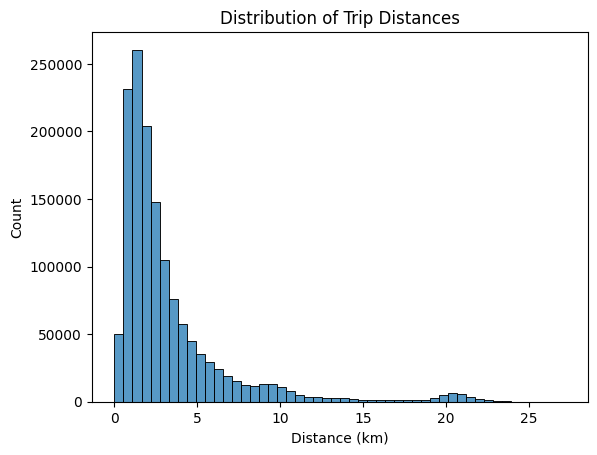

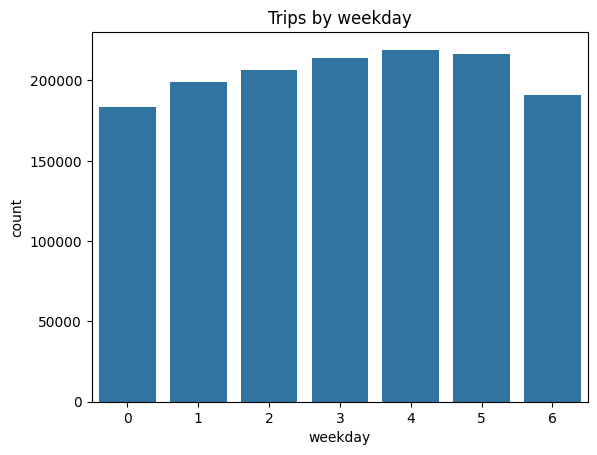

In [ ]:
# Distribution distances graph
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['distance_km'], bins=50)
plt.xlabel("Distance (km)")
plt.title("Distribution of Trip Distances")
plt.show()

sns.countplot(x='weekday', data=df)
plt.title("Trips by weekday")
plt.show()

### 7. Save in Parquet format

In [65]:
df.to_parquet(r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\NY Trip Duration\data\processed\cleaned_nyc_taxi.parquet", index=False)
print("Parque file saved!")

Parque file saved!


### 8. Queries with DuckDB

In [66]:
import duckdb

# Connect and consult Parquet
df = duckdb.read_parquet(r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\NY Trip Duration\data\processed\cleaned_nyc_taxi.parquet")

result = duckdb.query("""
    SELECT AVG(distance_km) AS avg_distance, weekday
    FROM df
    GROUP BY weekday
""").df()

print(result)

   avg_distance  weekday
0      3.441081        0
1      3.222664        1
2      3.219740        2
3      3.288753        3
4      3.274187        4
5      3.206701        5
6      3.578781        6


### 9. Generate visualizations

#### 9.1 Distribution Distance and Duration

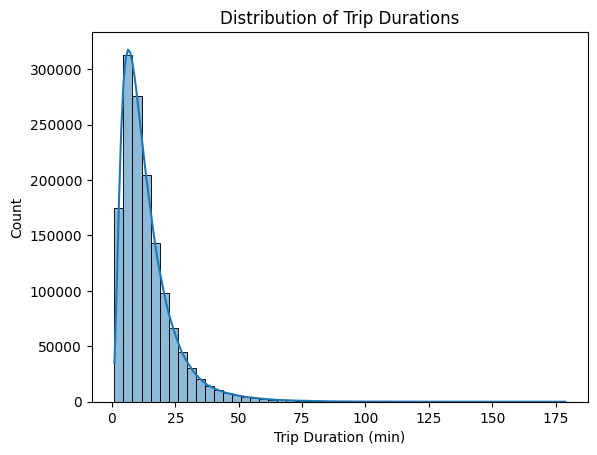

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet(
    r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\NY Trip Duration\data\processed\cleaned_nyc_taxi.parquet"
)
                                  
sns.histplot(df['trip_duration'] / 60, bins=50, kde=True)
plt.xlabel("Trip Duration (min)")
plt.title("Distribution of Trip Durations")
plt.show()


#### 9.2 Boxplots

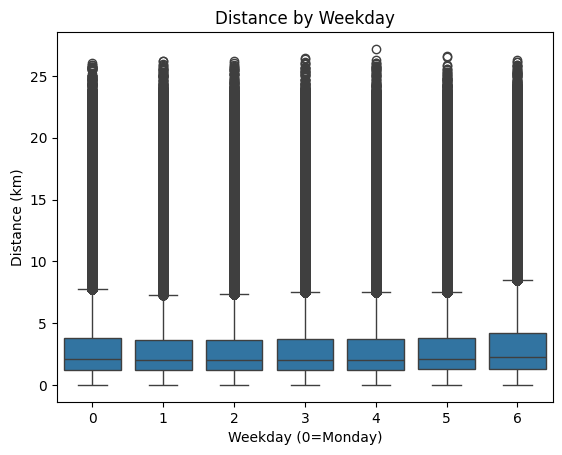

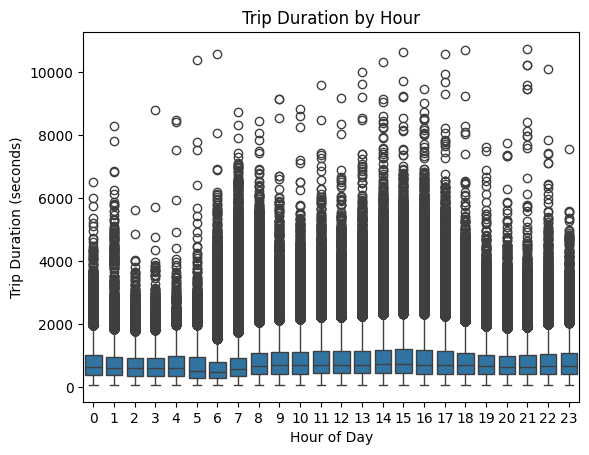

In [71]:
sns.boxplot(x='weekday', y='distance_km', data=df)
plt.xlabel("Weekday (0=Monday)")
plt.ylabel("Distance (km)")
plt.title("Distance by Weekday")
plt.show()

sns.boxplot(x='hour', y='trip_duration', data=df)
plt.xlabel("Hour of Day")
plt.ylabel("Trip Duration (seconds)")
plt.title("Trip Duration by Hour")
plt.show()

#### 9.3 Scatter Plots

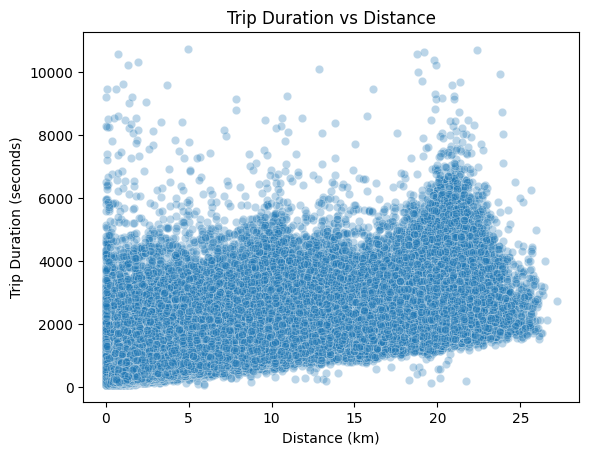

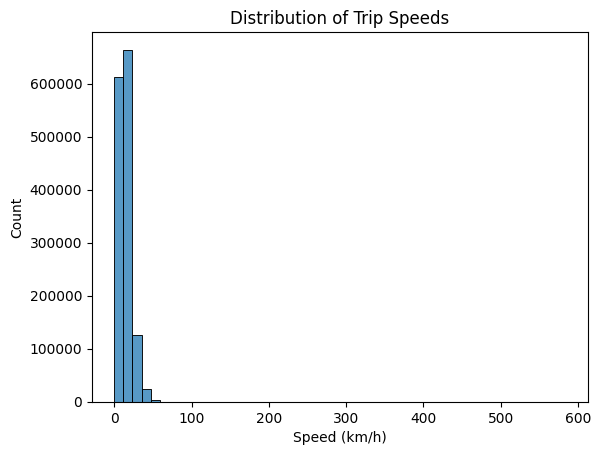

In [72]:
sns.scatterplot(x='distance_km', y='trip_duration', data=df, alpha=0.3)
plt.xlabel("Distance (km)")
plt.ylabel("Trip Duration (seconds)")
plt.title("Trip Duration vs Distance")
plt.show()

df['speed_kmh'] = df['distance_km'] / (df['trip_duration'] / 3600)
sns.histplot(df['speed_kmh'], bins=50)
plt.xlabel("Speed (km/h)")
plt.title("Distribution of Trip Speeds")
plt.show()

#### 9.4 Heatmap and Correlations

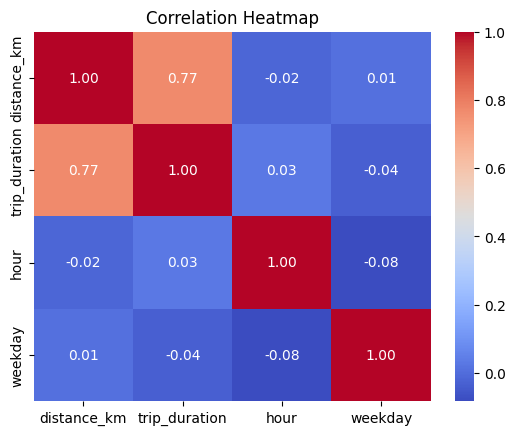

In [73]:
corr = df[['distance_km', 'trip_duration', 'hour', 'weekday']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### 9.5 Temporal Series

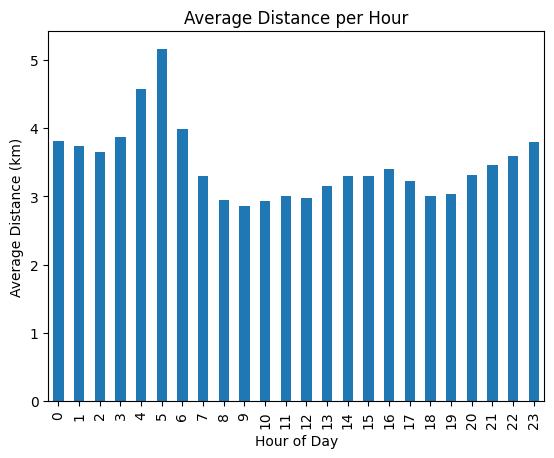

In [74]:
df.groupby('hour')['distance_km'].mean().plot(kind='bar')
plt.ylabel("Average Distance (km)")
plt.xlabel("Hour of Day")
plt.title("Average Distance per Hour")
plt.show()